In [1]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2024_Phase_Camera_FM_Design/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2
import torch
import torch.nn.functional as F

from scipy.ndimage import gaussian_filter
from scipy.signal import correlate2d, convolve2d, tukey
from scipy.interpolate import RegularGridInterpolator

from orthnet import Legendre

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


# Two reasons:

1. With large curvature (or even gradients), same speckle does not intersect with the image plane. The corresponding measured signal is simply a different one.
2. Diffraction effects at large distances. How do they play a role?

In [2]:
# 1d propagator

def propagate_1d(field, dist, wl, dx):

        k0 = 2 * torch.pi / wl
        Nx = field.shape[0]

        kx = torch.fft.fftfreq(Nx, dx) * 2 * torch.pi
        kz = torch.sqrt(k0**2 - kx**2)

        field_fft = torch.fft.fft(field)
        transfer_function = torch.exp(1j*kz*dist)
        out_field = torch.fft.ifft(field_fft * transfer_function)
        
        return out_field

In [3]:
# set system params

# Grid and propagation parameters setup
wl = 640e-9 # meters
n_0 = 1.

dx = 500e-9 # dx == dy
nx = 2000 # nx == ny

padding = 512
dist = 3e-3 # distance bw phase mask and image plane 

print(f'Spatial support: 0 -> {dx*nx/1e-3:.2f} mm')

Spatial support: 0 -> 1.00 mm


Height: 3.2e-07
(3024,) float64 20 100


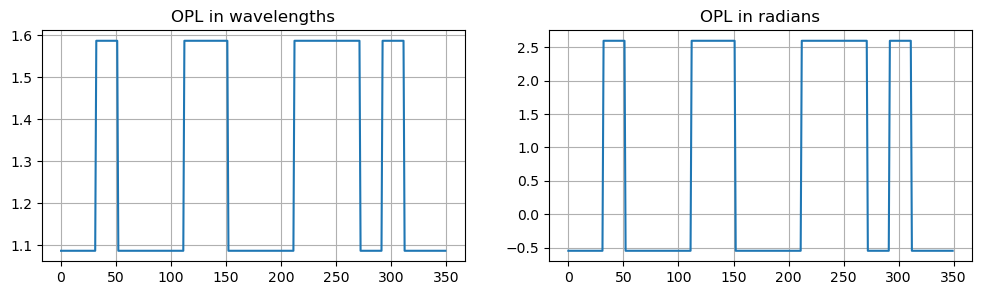

(torch.Size([3024, 3024]),
 <function Tensor.type>,
 tensor([[0.8544-0.5196j, 0.0000+0.0000j, 0.0000+0.0000j, 0.0000+0.0000j],
         [0.0000+0.0000j, 0.8544-0.5196j, 0.0000+0.0000j, 0.0000+0.0000j],
         [0.0000+0.0000j, 0.0000+0.0000j, 0.8544-0.5196j, 0.0000+0.0000j],
         [0.0000+0.0000j, 0.0000+0.0000j, 0.0000+0.0000j, 0.8544-0.5196j]],
        dtype=torch.complex128))

In [4]:
# create phase mask: 
# diagonal phase-only transmission matrix

side_length = 10e-6
tile_size = int(side_length/dx)
RI_pm = 1.46
height = wl/(2*(RI_pm - n_0)) #695e-9 # \pi/2 = 2\pi /wl * (RI_pm - 1)*h => h = wl/(2*(RI_pm - n_0))
print(f'Height: {height*(RI_pm - n_0)}')

prob = 0.5

nx_tiles = nx//tile_size
samples_mask = np.random.uniform(size=nx_tiles) > prob

# strucutres size-distance away from boundary
samples_mask[0] = 0.
samples_mask[-1] = 0.

h_map_pm = height*np.repeat(samples_mask, tile_size, axis=0)
h_map_pm = np.pad(h_map_pm, padding, 'edge')

opd_pm = h_map_pm*RI_pm + (h_map_pm.max() - h_map_pm)*n_0
t_diag = np.exp(-1j*(2*np.pi/wl)*opd_pm) # no negative sign? RI dense regions should lag behind so negative sign

print(h_map_pm.shape, h_map_pm.dtype, tile_size, nx_tiles)

fig, axs = plt.subplots(1, 2, figsize=(12, 3))

axs[0].plot(opd_pm[500:850]/wl)
axs[0].grid()
axs[0].set_title('OPL in wavelengths')

axs[1].plot(np.angle(t_diag[500:850]))
axs[1].grid()
axs[1].set_title('OPL in radians')

plt.show()

T_d = torch.diag(torch.from_numpy(t_diag))
T_d.shape, T_d.type, T_d[:4, :4]


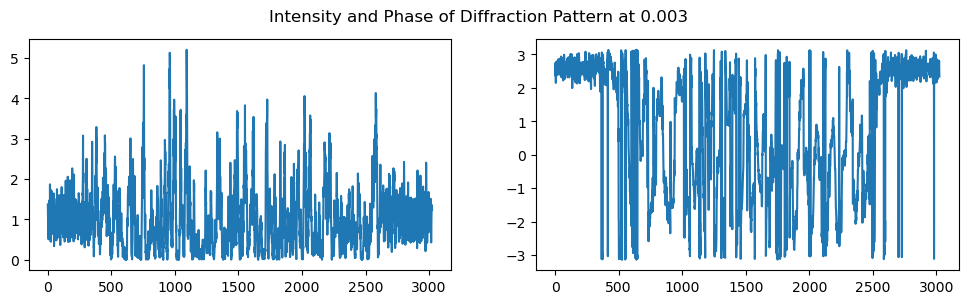

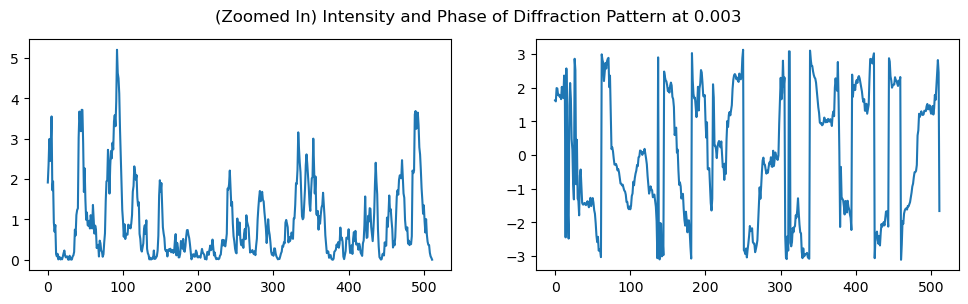

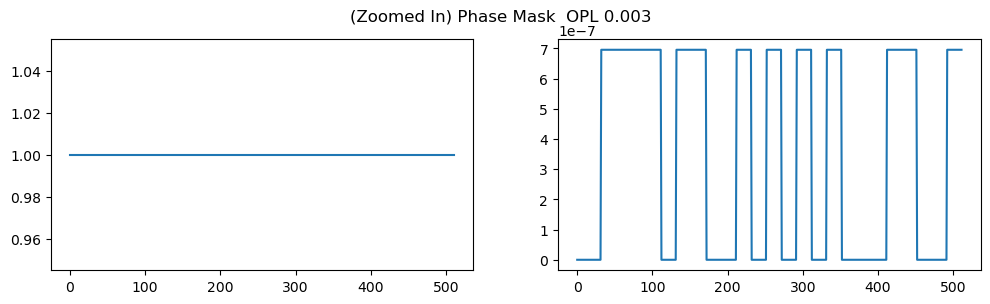

In [5]:
# reference wavefield: diffraction pattern of phase mask at dist

u_ir = propagate_1d(torch.matmul(T_d, torch.ones(T_d.shape[1], dtype=torch.complex128)), 
                    dist, wl, dx)

fig, axs = plt.subplots(1, 2, figsize=(12, 3))

plt.suptitle(f'Intensity and Phase of Diffraction Pattern at {dist}')

axs[0].plot(np.abs(u_ir)**2)
axs[1].plot(np.angle(u_ir))

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 3))

plt.suptitle(f'(Zoomed In) Intensity and Phase of Diffraction Pattern at {dist}')

axs[0].plot(np.abs(u_ir[1000:1512])**2)
axs[1].plot(np.angle(u_ir[1000:1512]))

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 3))

plt.suptitle(f'(Zoomed In) Phase Mask  OPL {dist}')

axs[0].plot(np.abs(t_diag[1000:1512])**2)
# axs[1].plot(np.angle(t_diag[1000:1512]))
axs[1].plot(h_map_pm[1000:1512])


plt.show()

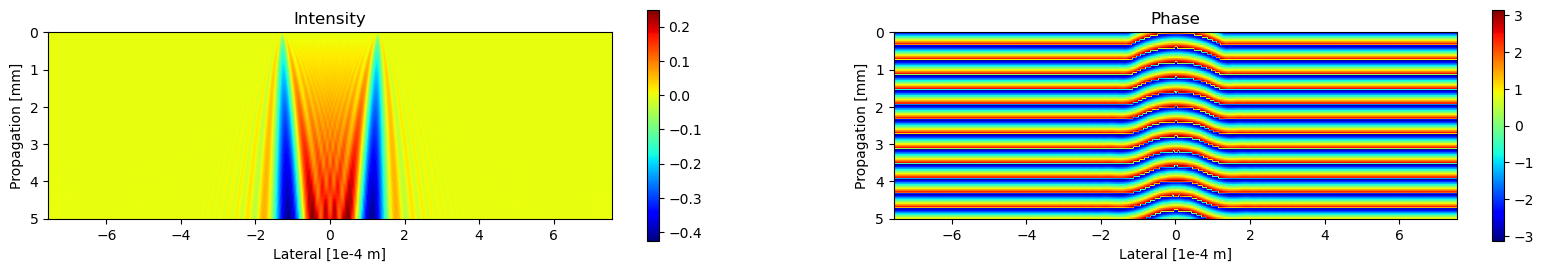

In [511]:
# converging wave
# \phi(x, y) = -k*sqrt(z_f**2 x**2 + y**2)
u_iconv_z = torch.zeros([101, u_ir.shape[0]], dtype=torch.complex128)

x_cords = torch.arange(-1*(nx/2 + padding) , nx/2 + padding)*dx
z_f = 15e-3 # m

phi_conv = torch.sqrt(z_f**2 + x_cords**2)

phi_conv[:1256] = phi_conv[1256]
phi_conv[1768:] = phi_conv[1768]

conv_field = torch.exp(-1j*(2*torch.pi/wl)*phi_conv).type(torch.complex128)

for idx, z in enumerate(np.linspace(0, 5, 101)):
    u_iconv_z[idx] = propagate_1d(conv_field, z*1e-3, wl, dx)
    # torch.matmul(T_d, conv_field)
fig, axs = plt.subplots(1, 2, figsize=(20, 3))

cm0 = axs[0].imshow(np.log10(torch.abs(u_iconv_z)**2), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm0, ax=axs[0])
axs[0].set_ylabel('Propagation [mm]')
axs[0].set_xlabel('Lateral [1e-4 m]')
axs[0].set_title('Intensity')

cm1 = axs[1].imshow(torch.angle(u_iconv_z), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm1, ax=axs[1])
axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Phase')

plt.show()

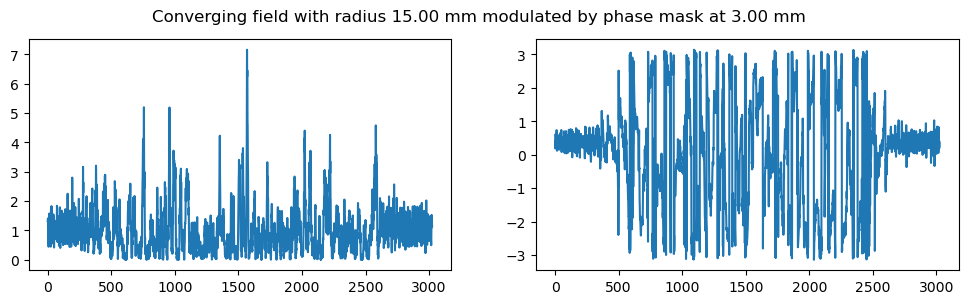

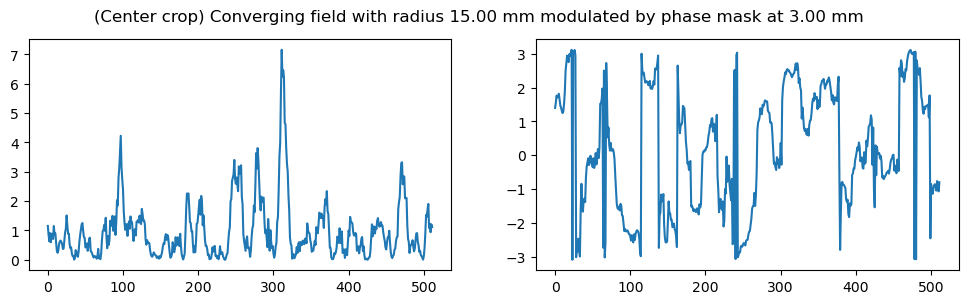

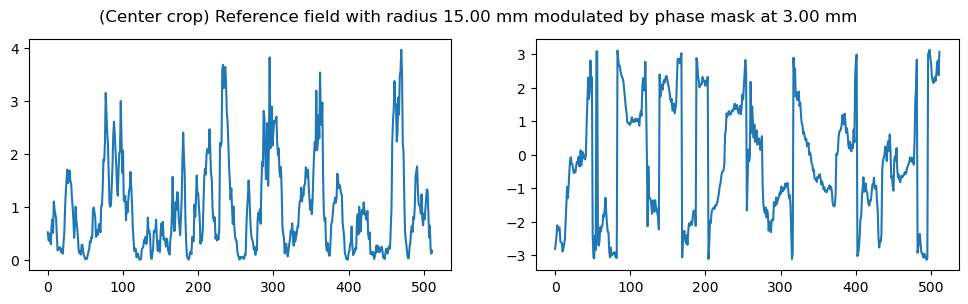

In [512]:
# converging wave
u_ir = propagate_1d(torch.matmul(T_d, torch.ones(T_d.shape[1], dtype=torch.complex128)), dist, wl, dx)
u_io = propagate_1d(torch.matmul(T_d, conv_field), dist, wl, dx)

fig, axs = plt.subplots(1, 2, figsize=(12, 3))

plt.suptitle(f'Converging field with radius {z_f/1e-3:.2f} mm modulated by phase mask at {dist/1e-3:.2f} mm')

axs[0].plot(np.abs(u_io)**2)
axs[1].plot(np.angle(u_io))

plt.show()

cx = int(u_ir.shape[0]/2)
fig, axs = plt.subplots(1, 2, figsize=(12, 3))

plt.suptitle(f'(Center crop) Converging field with radius {z_f/1e-3:.2f} mm modulated by phase mask at {dist/1e-3:.2f} mm')

axs[0].plot(np.abs(u_io[cx-256:cx+256])**2)
axs[1].plot(np.angle(u_io[cx-256:cx+256]))

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 3))

plt.suptitle(f'(Center crop) Reference field with radius {z_f/1e-3:.2f} mm modulated by phase mask at {dist/1e-3:.2f} mm')

axs[0].plot(np.abs(u_ir[cx-256:cx+256])**2)
axs[1].plot(np.angle(u_ir[cx-256:cx+256]))

plt.show()

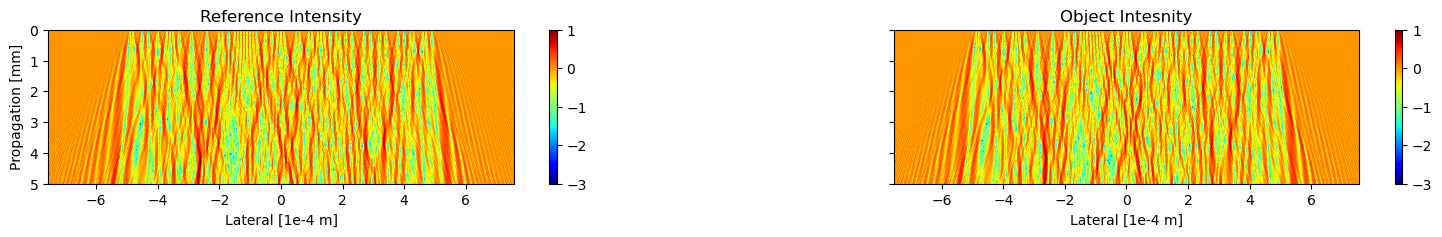

In [513]:
# converging wave

u_ir_z = torch.zeros([101, u_ir.shape[0]], dtype=torch.complex128)
u_io_z = torch.zeros([101, u_ir.shape[0]], dtype=torch.complex128)

for idx, z in enumerate(np.linspace(0, 5, 101)):
    u_ir_z[idx] = propagate_1d(T_d.diag(), z*1e-3, wl, dx)
    u_io_z[idx] = propagate_1d(torch.matmul(T_d, conv_field), z*1e-3, wl, dx)
    
fig, axs = plt.subplots(1, 2, figsize=(20, 2), sharey=True)

cm0 = axs[0].imshow(np.log10(torch.abs(u_ir_z)**2), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0], vmin=-3, vmax=1)
plt.colorbar(cm0, ax=axs[0])
axs[0].set_ylabel('Propagation [mm]')
axs[0].set_xlabel('Lateral [1e-4 m]')
axs[0].set_title('Reference Intensity')

cm1 = axs[1].imshow(np.log10(torch.abs(u_io_z)**2), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0], vmin=-3, vmax=1)
plt.colorbar(cm1, ax=axs[1])
# axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Object Intesnity')

plt.show()

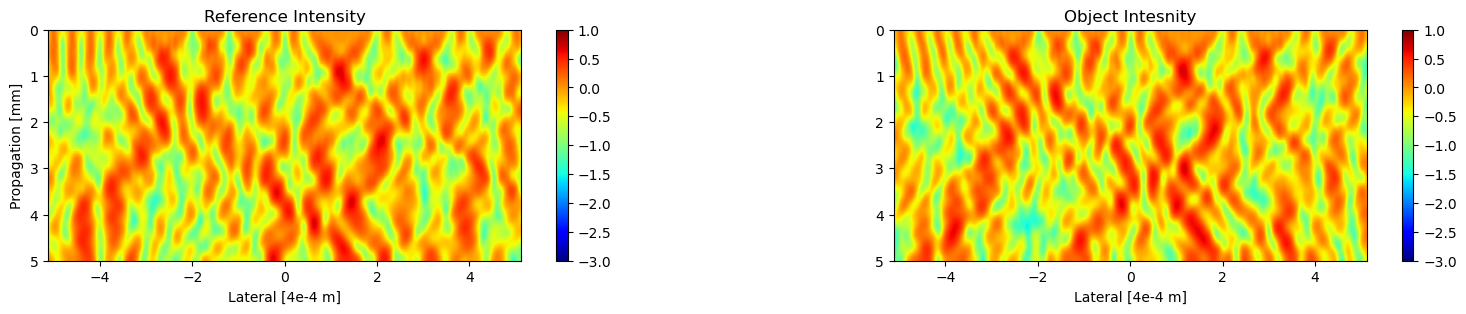

In [514]:
fig, axs = plt.subplots(1, 2, figsize=(20, 3), sharey=False)

fov = 256

cm0 = axs[0].imshow(gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 2), cmap='jet', extent=[-1*dx*fov*1e4*4, dx*fov*1e4*4, 5, 0], vmin=-3, vmax=1)
plt.colorbar(cm0, ax=axs[0])
axs[0].set_ylabel('Propagation [mm]')
axs[0].set_xlabel('Lateral [4e-4 m]')
axs[0].set_title('Reference Intensity')

cm1 = axs[1].imshow(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2), cmap='jet', extent=[-1*dx*fov*1e4*4, dx*fov*1e4*4, 5, 0], vmin=-3, vmax=1)
plt.colorbar(cm1, ax=axs[1])
# axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [4e-4 m]')
axs[1].set_title('Object Intesnity')

plt.show()

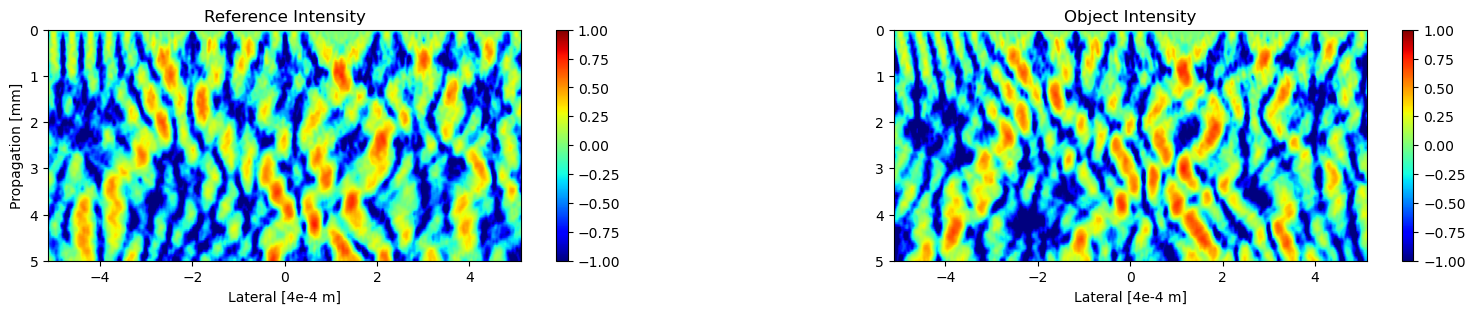

In [515]:
fig, axs = plt.subplots(1, 2, figsize=(20, 3), sharey=False)

fov = 256

cm0 = axs[0].imshow(np.where(gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 1) > -1, 
                             gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 1), -1), 
                    cmap='jet', extent=[-1*dx*fov*1e4*4, dx*fov*1e4*4, 5, 0], vmin=-1, vmax=1)
plt.colorbar(cm0, ax=axs[0])
axs[0].set_ylabel('Propagation [mm]')
axs[0].set_xlabel('Lateral [4e-4 m]')
axs[0].set_title('Reference Intensity')
# axs[0].grid()

cm1 = axs[1].imshow(np.where(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 1) > -1, 
                             gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 1), -1), 
                    cmap='jet', extent=[-1*dx*fov*1e4*4, dx*fov*1e4*4, 5, 0], vmin=-1, vmax=1)
plt.colorbar(cm1, ax=axs[1])
# axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [4e-4 m]')
axs[1].set_title('Object Intensity')
# axs[1].grid()

plt.show()

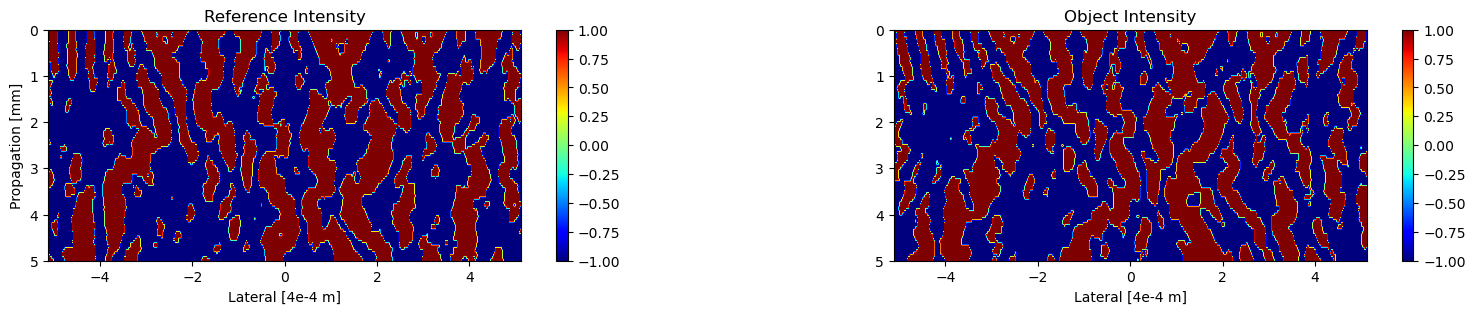

In [516]:
fig, axs = plt.subplots(1, 2, figsize=(20, 3), sharey=False)

fov = 256

cm0 = axs[0].imshow(np.where(gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 1) > -0.1, 
                             1, -1), 
                    cmap='jet', extent=[-1*dx*fov*1e4*4, dx*fov*1e4*4, 5, 0], vmin=-1, vmax=1)
plt.colorbar(cm0, ax=axs[0])
axs[0].set_ylabel('Propagation [mm]')
axs[0].set_xlabel('Lateral [4e-4 m]')
axs[0].set_title('Reference Intensity')
# axs[0].grid()

cm1 = axs[1].imshow(np.where(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 1) > -0.1, 
                             1, -1), 
                    cmap='jet', extent=[-1*dx*fov*1e4*4, dx*fov*1e4*4, 5, 0], vmin=-1, vmax=1)
plt.colorbar(cm1, ax=axs[1])
# axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [4e-4 m]')
axs[1].set_title('Object Intensity')
# axs[1].grid()

plt.show()

In [517]:
# fig, axs = plt.subplots(1, 2, figsize=(20, 4))
# axs[0].plot(np.arange(-fov, fov)*dx/0.25e-4, np.where(gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 2) > -0.01, 
#                                                       gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 2), 0.)[20, :], label='ref')
# axs[0].plot(np.arange(-fov, fov)*dx/0.25e-4, np.where(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2) > -0.01, 
#                                                       gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2), 0.)[20, :], label='obj')
# axs[0].legend()


# axs[1].plot(np.arange(-fov, fov)*dx/0.25e-4, np.where(gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 2) > -0.01, 
#                                                       gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 2), 0.)[80, :], label='ref')
# axs[1].plot(np.arange(-fov, fov)*dx/0.25e-4, np.where(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2) > -0.01, 
#                                                       gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2), 0.)[80, :], label='obj')
# axs[1].legend()

# plt.show()

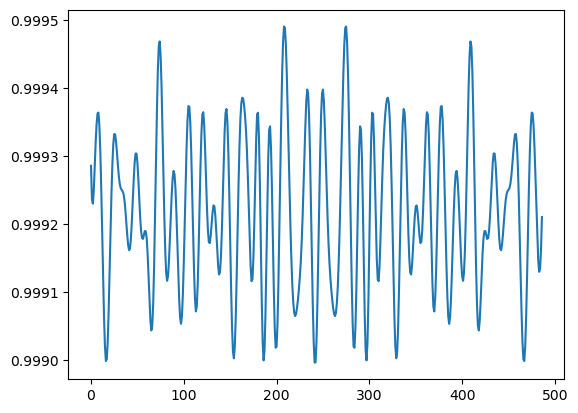

In [528]:
plt.plot(1 - lap[15:-10])

Text(0.5, 0.98, 'Intensities at d = 1 mm')

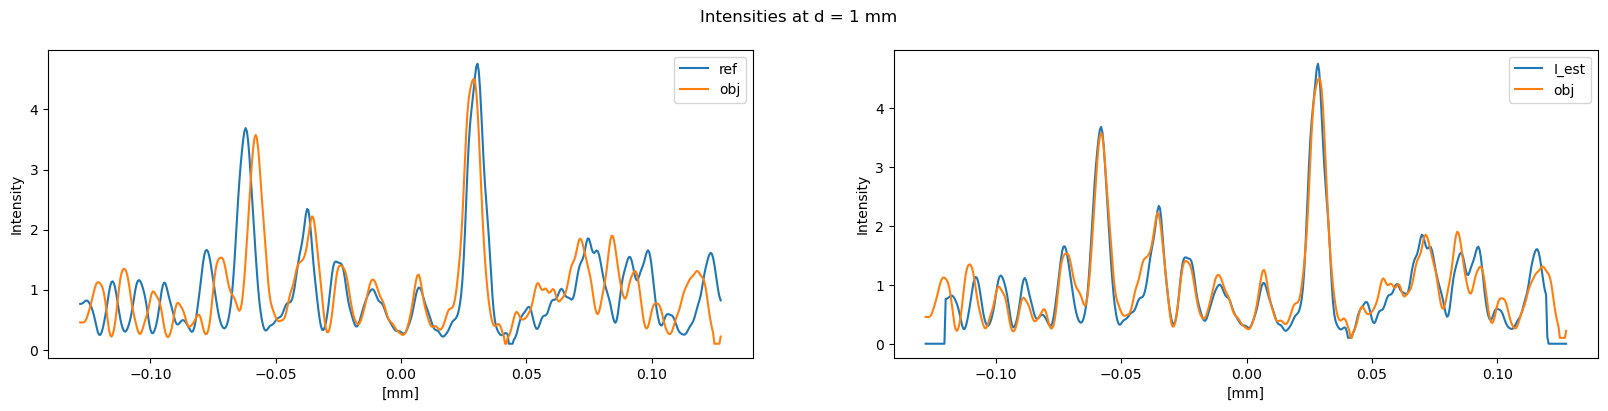

In [519]:
# repeat above and replace ref with displaced flow reference so that obj and ref would be same if featues remained same
x = torch.linspace(-1, 1, fov*2, dtype=torch.float64)

X_grid, Y_grid = torch.meshgrid((x, torch.tensor([1.], dtype=torch.float64))) # 1d data but grid sample works for 2d
grad_optr = torch.tensor([-1., 1. , 0.], dtype=torch.float64)

grad_phi =  F.conv1d(phi_conv[cx-fov:cx+fov].double().unsqueeze(0).unsqueeze(0), grad_optr.unsqueeze(0).unsqueeze(0), padding='same').squeeze()
grad_phi[0] = 0.
g_flow = gaussian_filter(grad_phi.unsqueeze(1)/dx*1e-3/(1*fov*dx), 3)
X_grid_warped = X_grid + g_flow
# X_grid_clamped = X_grid_warped.clamp(-1, 1)
grid = torch.hstack((Y_grid.unsqueeze(-1), X_grid_warped.unsqueeze(-1))).permute(0, 2, 1).unsqueeze(0)  # Shape: (1, N, 1, 2)

I0 = np.where(gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 2) > -1, 
                                                      gaussian_filter((torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 2), 0.1)[20, :]

I_est = F.grid_sample(torch.tensor(I0).unsqueeze(0).unsqueeze(0).unsqueeze(-1), grid, align_corners=True, mode='bilinear').squeeze()

lap = torch.gradient(torch.tensor(g_flow), dim=0)[0].squeeze()

I_est = (1 - lap)*I_est

fig, axs = plt.subplots(1, 2, figsize=(20, 4))
axs[0].plot(np.arange(-fov, fov)*dx/1e-3, I0, label='ref')
axs[0].plot(np.arange(-fov, fov)*dx/1e-3, np.where(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2) > -1, 
                                                      gaussian_filter((torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2), 0.1)[20, :], label='obj')
axs[0].legend()

axs[1].plot(np.arange(-fov, fov)*dx/1e-3, I_est, label='I_est')
axs[1].plot(np.arange(-fov, fov)*dx/1e-3, np.where(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2) > -1, 
                                                      gaussian_filter((torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2), 0.1)[20, :], label='obj')
axs[1].legend()

axs[0].set_xlabel('[mm]')
axs[0].set_ylabel('Intensity')

axs[1].set_xlabel('[mm]')
axs[1].set_ylabel('Intensity')

plt.suptitle('Intensities at d = 1 mm')

Text(0.5, 0.98, 'Intensities at d = 2 mm')

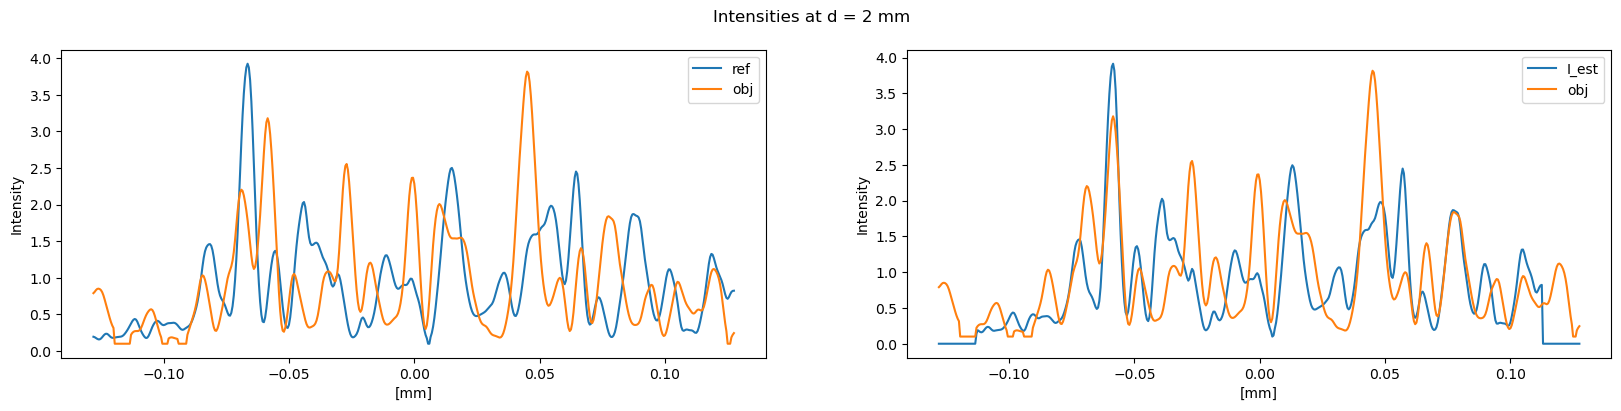

In [520]:
# repeat above and replace ref with displaced flow reference so that obj and ref would be same if featues remained same
x = torch.linspace(-1, 1, fov*2, dtype=torch.float64)

X_grid, Y_grid = torch.meshgrid((x, torch.tensor([1.], dtype=torch.float64))) # 1d data but grid sample works for 2d
grad_optr = torch.tensor([-1., 1. , 0.], dtype=torch.float64)

grad_phi =  F.conv1d(phi_conv[cx-fov:cx+fov].double().unsqueeze(0).unsqueeze(0), grad_optr.unsqueeze(0).unsqueeze(0), padding='same').squeeze()
grad_phi[0] = 0.

g_flow = gaussian_filter(grad_phi.unsqueeze(1)/dx*2e-3/(1*fov*dx), 3)
X_grid_warped = X_grid + g_flow
# X_grid_clamped = X_grid_warped.clamp(-1, 1)

grid = torch.hstack((Y_grid.unsqueeze(-1), X_grid_warped.unsqueeze(-1))).permute(0, 2, 1).unsqueeze(0)  # Shape: (1, N, 1, 2)

I0 = np.where(gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 2) > -1, 
                                                      gaussian_filter((torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 2), 0.1)[40, :]

I_est = F.grid_sample(torch.tensor(I0).unsqueeze(0).unsqueeze(0).unsqueeze(-1), grid, align_corners=True, mode='bilinear').squeeze()

lap = torch.gradient(torch.tensor(g_flow), dim=0)[0].squeeze()

I_est = (1 - lap)*I_est

fig, axs = plt.subplots(1, 2, figsize=(20, 4))
axs[0].plot(np.arange(-fov, fov)*dx/1e-3, I0, label='ref')
axs[0].plot(np.arange(-fov, fov)*dx/1e-3, np.where(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2) > -1, 
                                                      gaussian_filter((torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2), 0.1)[40, :], label='obj')
axs[0].legend()

axs[1].plot(np.arange(-fov, fov)*dx/1e-3, I_est, label='I_est')
axs[1].plot(np.arange(-fov, fov)*dx/1e-3, np.where(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2) > -1, 
                                                      gaussian_filter((torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2), 0.1)[40, :], label='obj')
axs[1].legend()

axs[0].set_xlabel('[mm]')
axs[0].set_ylabel('Intensity')

axs[1].set_xlabel('[mm]')
axs[1].set_ylabel('Intensity')

plt.suptitle('Intensities at d = 2 mm')

Text(0.5, 0.98, 'Intensities at d = 3 mm')

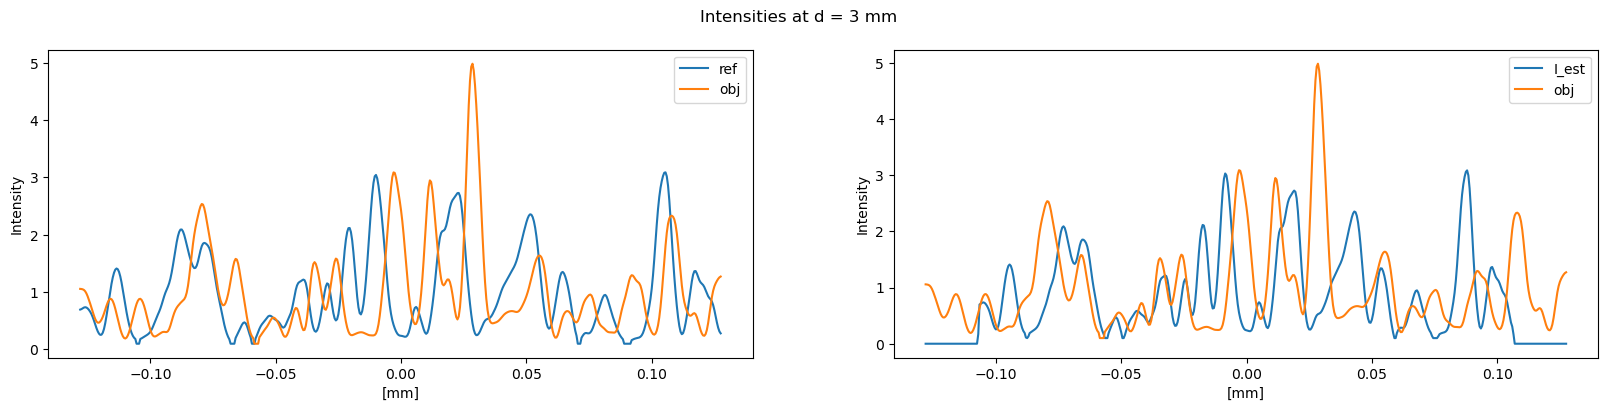

In [521]:
# repeat above and replace ref with displaced flow reference so that obj and ref would be same if featues remained same
x = torch.linspace(-1, 1, fov*2, dtype=torch.float64)

X_grid, Y_grid = torch.meshgrid((x, torch.tensor([1.], dtype=torch.float64))) # 1d data but grid sample works for 2d
grad_optr = torch.tensor([-1., 1. , 0.], dtype=torch.float64)

grad_phi =  F.conv1d(phi_conv[cx-fov:cx+fov].double().unsqueeze(0).unsqueeze(0), grad_optr.unsqueeze(0).unsqueeze(0), padding='same').squeeze()
grad_phi[0] = 0.

g_flow = gaussian_filter(grad_phi.unsqueeze(1)/dx*3e-3/(1*fov*dx), 5)
X_grid_warped = X_grid + g_flow
# X_grid_clamped = X_grid_warped.clamp(-1, 1)
grid = torch.hstack((Y_grid.unsqueeze(-1), X_grid_warped.unsqueeze(-1))).permute(0, 2, 1).unsqueeze(0)  # Shape: (1, N, 1, 2)

I0 = np.where(gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 2) > -1, 
                                                      gaussian_filter((torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 2), 0.1)[60, :]

I_est = F.grid_sample(torch.tensor(I0).unsqueeze(0).unsqueeze(0).unsqueeze(-1), grid, align_corners=True, mode='bilinear').squeeze()

lap = torch.gradient(torch.tensor(g_flow), dim=0)[0].squeeze()

I_est = (1 - lap)*I_est

fig, axs = plt.subplots(1, 2, figsize=(20, 4))
axs[0].plot(np.arange(-fov, fov)*dx/1e-3, I0, label='ref')
axs[0].plot(np.arange(-fov, fov)*dx/1e-3, np.where(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2) > -1, 
                                                      gaussian_filter((torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2), 0.1)[60, :], label='obj')
axs[0].legend()

axs[1].plot(np.arange(-fov, fov)*dx/1e-3, I_est, label='I_est')
axs[1].plot(np.arange(-fov, fov)*dx/1e-3, np.where(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2) > -1, 
                                                      gaussian_filter((torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 2), 0.1)[60, :], label='obj')
axs[1].legend()

axs[0].set_xlabel('[mm]')
axs[0].set_ylabel('Intensity')

axs[1].set_xlabel('[mm]')
axs[1].set_ylabel('Intensity')

plt.suptitle('Intensities at d = 3 mm')


In [522]:
u_iest_z = torch.zeros([101, fov*2], dtype=torch.complex128)

# repeat above and replace ref with displaced flow reference so that obj and ref would be same if featues remained same
x = torch.linspace(-1, 1, fov*2, dtype=torch.float64)

X_grid, Y_grid = torch.meshgrid((x, torch.tensor([1.], dtype=torch.float64))) # 1d data but grid sample works for 2d
grad_optr = torch.tensor([-1., 1. , 0.], dtype=torch.float64)

grad_phi =  F.conv1d(phi_conv[cx-fov:cx+fov].double().unsqueeze(0).unsqueeze(0), grad_optr.unsqueeze(0).unsqueeze(0), padding='same').squeeze()
grad_phi[0] = 0.

for idx, z in enumerate(np.linspace(0, 5, 101)):
    X_grid_warped = X_grid + gaussian_filter(grad_phi.unsqueeze(1)/dx*z*1e-3/(1*fov*dx), 5)
    grid = torch.hstack((Y_grid.unsqueeze(-1), X_grid_warped.unsqueeze(-1))).permute(0, 2, 1).unsqueeze(0)  # Shape: (1, N, 1, 2)

    I0 = torch.abs(u_ir_z[idx, cx-fov:cx+fov])**2
    u_iest_z[idx, :] = F.grid_sample(torch.tensor(I0).unsqueeze(0).unsqueeze(0).unsqueeze(-1), grid, align_corners=True, mode='bilinear').squeeze()

/tmp/ipykernel_33454/2027711597.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  u_iest_z[idx, :] = F.grid_sample(torch.tensor(I0).unsqueeze(0).unsqueeze(0).unsqueeze(-1), grid, align_corners=True, mode='bilinear').squeeze()


/tmp/ipykernel_33454/255216544.py:14: RuntimeWarning: divide by zero encountered in log10
  cm1 = axs[1].imshow(np.where(gaussian_filter(np.log10(torch.abs(u_iest_z)), 1) > -0.1,


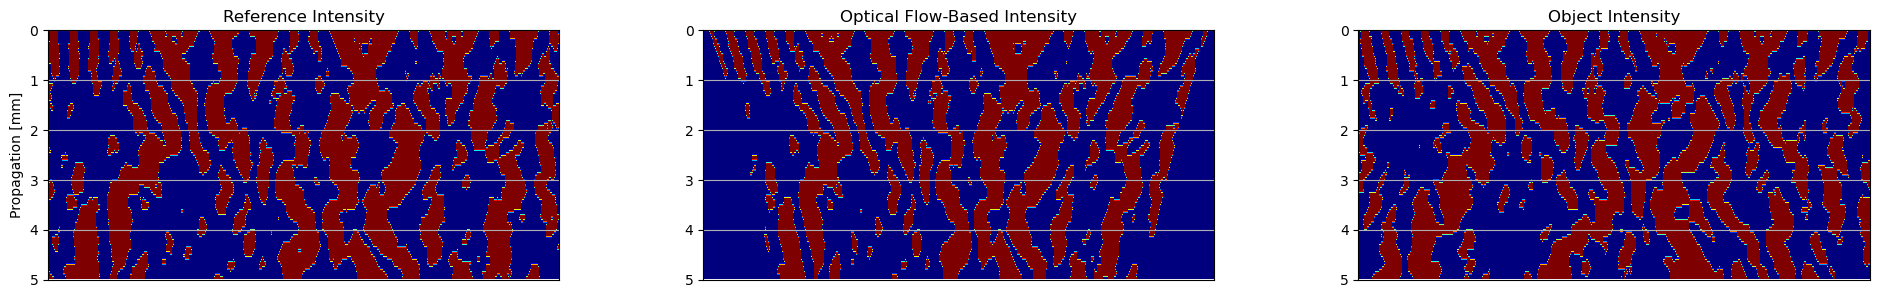

In [523]:
fig, axs = plt.subplots(1, 3, figsize=(20, 3), sharey=False)

fov = 256

cm0 = axs[0].imshow(np.where(gaussian_filter(np.log10(torch.abs(u_ir_z[:, cx-fov:cx+fov])**2), 1) > -0.1, 
                             1, -1), 
                    cmap='jet', extent=[-1*dx*fov*1e4*4, dx*fov*1e4*4, 5, 0], vmin=-1, vmax=1)
# plt.colorbar(cm0, ax=axs[0])
axs[0].set_ylabel('Propagation [mm]')
# axs[0].set_xlabel('Lateral [4e-4 m]')
axs[0].set_title('Reference Intensity')
axs[0].grid()

cm1 = axs[1].imshow(np.where(gaussian_filter(np.log10(torch.abs(u_iest_z)), 1) > -0.1, 
                             1, -1), 
                    cmap='jet', extent=[-1*dx*fov*1e4*4, dx*fov*1e4*4, 5, 0], vmin=-1, vmax=1)
# plt.colorbar(cm1, ax=axs[1])
# axs[1].set_ylabel('Propagation [mm]')
# axs[1].set_xlabel('Lateral [4e-4 m]')
axs[1].set_title('Optical Flow-Based Intensity')
axs[1].grid()

cm2 = axs[2].imshow(np.where(gaussian_filter(np.log10(torch.abs(u_io_z[:, cx-fov:cx+fov])**2), 1) > -0.1, 
                             1, -1), 
                    cmap='jet', extent=[-1*dx*fov*1e4*4, dx*fov*1e4*4, 5, 0], vmin=-1, vmax=1)
# plt.colorbar(cm2, ax=axs[2])
# axs[2].set_ylabel('Propagation [mm]')
# axs[2].set_xlabel('Lateral [4e-4 m]')
axs[2].set_title('Object Intensity')
axs[2].grid()

for i in range(3):
    axs[i].set_xticks(list([]))

plt.tight_layout()
plt.show()